<a href="https://colab.research.google.com/github/adilsaleem007/Python-Basics-Assignment/blob/main/case_study_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1) Downloading dataset from kaggle

In [4]:
import kagglehub


path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

print("Path to dataset files:", path)

100%|██████████| 1.98G/1.98G [00:20<00:00, 106MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8


# 2) Setting Training and Test path

In [5]:
import os

train_dir = os.path.join(path, "train")
test_dir = os.path.join(path, "test")

print(os.listdir(train_dir))

['corn', 'onion', 'pear', 'mango', 'kiwi', 'peas', 'paprika', 'carrot', 'watermelon', 'apple', 'orange', 'cucumber', 'capsicum', 'eggplant', 'chilli pepper', 'bell pepper', 'pineapple', 'jalepeno', 'lettuce', 'sweetpotato', 'turnip', 'soy beans', 'cabbage', 'beetroot', 'garlic', 'raddish', 'pomegranate', 'tomato', 'lemon', 'sweetcorn', 'potato', 'spinach', 'grapes', 'ginger', 'cauliflower', 'banana']


# 3) Binary Classification

In [6]:
import shutil

target = "/content/dataset_binary/train"

fruits = ['banana','apple','pear','grapes','orange','kiwi','watermelon','pomegranate','pineapple','mango']

os.makedirs(os.path.join(target, 'fruit'), exist_ok=True)
os.makedirs(os.path.join(target, 'vegetable'), exist_ok=True)

for folder in os.listdir(train_dir):
    folder_path = os.path.join(train_dir, folder)

    if folder.lower() in fruits:
        dest = os.path.join(target, 'fruit')
    else:
        dest = os.path.join(target, 'vegetable')

    for img in os.listdir(folder_path):
        shutil.copy(os.path.join(folder_path, img), dest)

# 4) Image Preprocessing

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "/content/dataset_binary/train",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "/content/dataset_binary/train",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 347 images belonging to 2 classes.
Found 86 images belonging to 2 classes.


# 5) Model Development

In [8]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 6)Compile and train

In [9]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(train_data, validation_data=val_data, epochs=8)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.5648 - loss: 0.7893 - val_accuracy: 0.5930 - val_loss: 0.6828
Epoch 2/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5937 - loss: 0.6581 - val_accuracy: 0.5930 - val_loss: 0.6564
Epoch 3/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.6542 - loss: 0.6104 - val_accuracy: 0.6512 - val_loss: 0.6011
Epoch 4/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.7176 - loss: 0.5301 - val_accuracy: 0.6279 - val_loss: 0.6423
Epoch 5/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.7896 - loss: 0.4710 - val_accuracy: 0.6860 - val_loss: 0.6425
Epoch 6/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.8300 - loss: 0.3876 - val_accuracy: 0.7907 - val_loss: 0.5365
Epoch 7/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8444 - loss: 0.3275 - val_accuracy: 0.7209 - val_loss: 0.5792
Epoch 8/8
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.8588 - loss: 0.3339 - val_accuracy: 0.6744 - val_loss: 0.7109


# 7) Accuracy

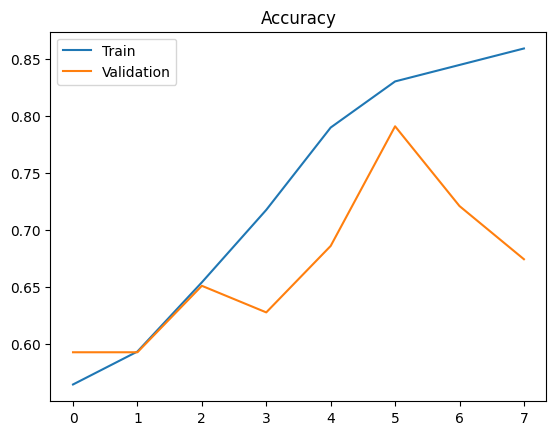

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy")
plt.show()

# Performing sample uploads to test

In [15]:
from google.colab import files
uploaded = files.upload()

Saving Image_3.jpg to Image_3.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


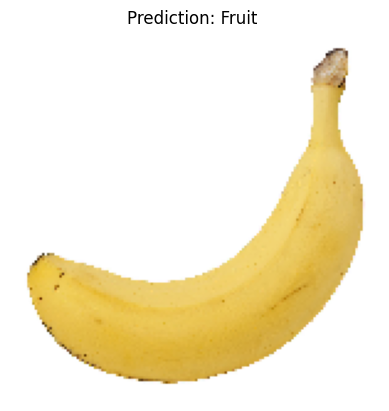

In [16]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

# Show image
plt.imshow(img)
plt.axis('off')

# Prediction
if prediction[0][0] > 0.5:
    label = "Vegetable "
else:
    label = "Fruit "

plt.title(f"Prediction: {label}")
plt.show()

In [17]:
from google.colab import files
uploaded = files.upload()

Saving Image_6.jpg to Image_6.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


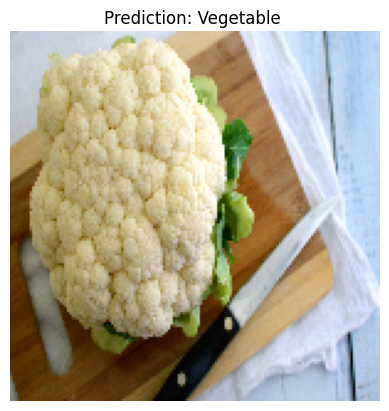

In [18]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

# Show image
plt.imshow(img)
plt.axis('off')

# Prediction
if prediction[0][0] > 0.5:
    label = "Vegetable "
else:
    label = "Fruit "

plt.title(f"Prediction: {label}")
plt.show()